Middleware
- Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

![alt text](image.png)

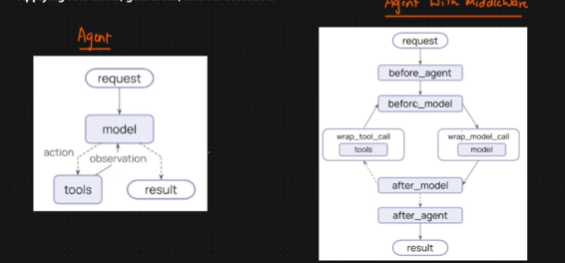


Summarization MiddleWare
- Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:openai/gpt-oss-120b")


In [ ]:

from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

### Messagebased summarization
agent=create_agent(
    model=model,
    checkpointer=InMemorySaver(),#Agent ki state ko checkpoint/memory mein store karega.
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("messages",10),#10 messag limit reached
            keep=("messages",4)#latest 4 mssges + summary
        )
    ]
)

In [ ]:
### Run with thread id
###thread_id = conversation/session ki unique ID,
#  jiske basis par LangGraph checkpointer us 
# conversation ki state/memory ko store aur retrieve karta hai.
config={"configurable":{"thread_id":"test-1"}}


In [12]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
    
   
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {len(response['messages'])}")
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: 8
Messages: {'messages': [HumanMessage(content="Here is a summary of the conversation to date:\n\n## SESSION INTENT\nProvide correct answers to the user's arithmetic questions (and any other informational queries as requested).\n\n## SUMMARY\n- Answered arithmetic queries:\n  - 2\u202f+\u202f2\u202f=\u202f4\n  - 10\u202f×\u202f5\u202f=\u202f50\n  - 100\u202f÷\u202f4\u202f=\u202f25\n- User has asked a new arithmetic question: “What is 15‑7?” (response pending).\n\n## ARTIFACTS\nNone\n\n## NEXT STEPS\nRespond to the pending arithmetic query “What is 15‑7?” with the correct result (8).", additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='c5bc10ed-cd8d-4d57-8453-a49ae3a1fa52'), AIMessage(content='15\u202f−\u202f7\u202f=\u202f8.', additional_kwargs={'reasoning_content': 'User asks arithmetic: 15-7 = 8. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 300, 'total_tokens': 335, 'completion_time': 0.073899062, 'c